# Per-Engine Cost Model: Random Forest + Gradient Boosting + Voting Ensemble

## Strategy
Train **separate models** for PostgreSQL and MySQL — no domain adaptation needed.
Each engine gets its own feature selection, hyperparameter tuning, and evaluation.

## Pipeline per engine
1. Load, clean, split (workload-stratified 70/10/20 train/val/test)
2. Feature group exploration — which groups carry signal?
3. Permutation importance → select best feature subset
4. RandomForest + HistGradientBoosting individually
5. VotingRegressor ensemble of the two
6. WorkloadGroupKFold cross-validation on train+val
7. Final evaluation on locked-away test set

## On 'accuracy' for regression
Three complementary metrics replace accuracy:
- **workload_spearman_macro** — mean Spearman within each workload (primary)
- **overall_spearman** — global rank correlation
- **top3_rank_accuracy** — % of queries whose predicted rank is within 3 of true rank
- **mape_pct** — mean absolute % error within workloads

## 0. Imports

In [28]:
import ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, rankdata
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    VotingRegressor,
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import BaseCrossValidator
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 1. Load & Merge

In [29]:
df3 = pd.read_csv('df3_semantic_features.csv')
col = pd.read_csv('cost_model_collected.csv')

key_map = {
    'metadata.benchmark':              'benchmark',
    'metadata.db_engine':              'db_engine',
    'metadata.hardware':               'hardware',
    'metadata.hardware_specs.cores':   'cores',
    'metadata.hardware_specs.ram_gb':  'ram_gb',
    'metadata.hardware_specs.threads': 'threads',
    'metadata.workload':               'workload',
}
col_m   = col.rename(columns=key_map)
merged  = df3.merge(col_m, how='left', on=list(key_map.values()),
                    suffixes=('', '_col'), validate='m:1', indicator=True)
merged['db_engine_norm'] = (merged['db_engine'].astype(str)
                              .str.strip().str.lower()
                              .replace({'mqsql': 'mysql'}))
da = merged[merged['db_engine_norm'].isin(['postgresql', 'mysql'])].copy()
da = da[da['ram_gb'].isin([32, 64])].copy()
print('Raw counts:'); print(da['db_engine_norm'].value_counts())

Raw counts:
db_engine_norm
postgresql    13590
mysql          1314
Name: count, dtype: int64


## 2. Data Cleaning

In [30]:
print(f'Rows before: {len(da)}')

# OLTP fix: negative cost values represent throughput; convert to latency = 1 / throughput.
# Stored throughput is negative, so throughput = -cost and latency = 1/(-cost) = -1/cost.
oltp_benchmarks = {'tpcc', 'smallbank', 'ycsb', 'twitter', 'wikipedia'}
bench_norm = da['benchmark'].astype(str).str.strip().str.lower()
oltp_neg_mask = bench_norm.isin(oltp_benchmarks) & da['cost'].notna() & (da['cost'] < 0)

n_oltp_neg = int(oltp_neg_mask.sum())
if n_oltp_neg > 0:
    idx = da.index[oltp_neg_mask]
    throughput = (-da.loc[idx, 'cost']).astype(float)
    positive_tp = throughput > 0
    if int(positive_tp.sum()) > 0:
        da.loc[idx[positive_tp], 'cost'] = 1.0 / throughput[positive_tp]
    da['cost'] = da['cost'].replace([np.inf, -np.inf], np.nan)

print(f'OLTP conversion: {n_oltp_neg} negative-cost rows detected')

# Remove sentinel / corrupted cost values
da = da[da['cost'].notna()].copy()
da = da[da['cost'] >= 0].copy()

# Clip extreme tails (fixes PG 64GB mean=-6832 outlier contamination)
lo, hi = da['cost'].quantile(0.001), da['cost'].quantile(0.999)
da = da[da['cost'].between(lo, hi)].copy()
print(f'After cleaning: {len(da)} rows  (cost clipped to [{lo:.4f}, {hi:.4f}])')
print(da.groupby(['db_engine_norm', 'ram_gb'])['cost'].describe().round(3))

Rows before: 14904
OLTP conversion: 5296 negative-cost rows detected
After cleaning: 14774 rows  (cost clipped to [-0.0000, 43.8341])
                         count    mean     std    min    25%     50%     75%  \
db_engine_norm ram_gb                                                          
mysql          32       1198.0  18.137  13.966  2.420  5.523  10.420  34.957   
               64         35.0  16.991  12.317  2.640  7.852  12.812  23.289   
postgresql     32       1212.0   1.542   1.744  0.205  0.415   1.064   1.662   
               64      12329.0   1.557   2.228 -0.000  0.000   0.257   2.584   

                          max  
db_engine_norm ram_gb          
mysql          32      43.773  
               64      42.410  
postgresql     32       8.988  
               64      12.472  


## 3. Feature Groups

Named groups let us test each combination independently before selecting
the best feature set for full training.

In [31]:
EXCLUDE = {
    'cost', '_merge', 'db_engine_norm', 'benchmark', 'db_engine',
    'hardware', 'workload', 'domain_name', 'metadata.source_collected_data',
    'metadata.workload_key', 'collected.query_plans', 'qp_emb_vector',
}
all_num = [
    c for c in da.columns
    if c not in EXCLUDE and pd.api.types.is_numeric_dtype(da[c])
]
sparsity = da[all_num].isna().mean()
all_num  = [c for c in all_num if sparsity[c] < 0.995]

def keep(cols):
    return [c for c in cols if c in all_num]

HARDWARE_COLS   = keep(['ram_gb', 'cores', 'threads'])
QUERY_PLAN_COLS = keep([c for c in all_num if any(x in c.lower() for x in
    ['node','plan','scan','join','sort','hash','index','seq','nest','loop',
     'rows','width','cost_est'])])
STAT_COLS       = keep([c for c in all_num if any(x in c.lower() for x in
    ['stat','table','bloat','dead','live','vacuum','analyze','heap','page',
     'tuple','frag'])])
RUNTIME_COLS    = keep([c for c in all_num if any(x in c.lower() for x in
    ['time','duration','exec','latency','ms','sec'])])
SEMANTIC_COLS   = keep([c for c in all_num if c.startswith('qp_emb_') or
    any(x in c.lower() for x in ['embed','semantic','tfidf','vec'])])

NAMED        = set(HARDWARE_COLS+QUERY_PLAN_COLS+STAT_COLS+RUNTIME_COLS+SEMANTIC_COLS)
OTHER_COLS   = [c for c in all_num if c not in NAMED]
ALL_FEAT_COLS = all_num
if 'ram_gb' not in ALL_FEAT_COLS:
    ALL_FEAT_COLS = ['ram_gb'] + ALL_FEAT_COLS

FEATURE_GROUPS = {
    'hardware':    HARDWARE_COLS,
    'query_plan':  QUERY_PLAN_COLS,
    'stats':       STAT_COLS,
    'runtime':     RUNTIME_COLS,
    'semantic':    SEMANTIC_COLS,
    'other':       OTHER_COLS,
    'all':         ALL_FEAT_COLS,
}
print('Feature groups:')
for name, cols in FEATURE_GROUPS.items():
    print(f'  {name:12s}: {len(cols):3d} features')

Feature groups:
  hardware    :   3 features
  query_plan  :   1 features
  stats       :  81 features
  runtime     :   2 features
  semantic    :   0 features
  other       :  66 features
  all         : 152 features


## 4. Metrics

In [32]:
def safe_spearman(yt, yp):
    if len(yt) < 3 or np.all(yt == yt[0]) or np.all(yp == yp[0]):
        return float('nan')
    return float(spearmanr(yt, yp)[0])


def workload_spearman_macro(y_true, y_pred, workloads, min_n=3):
    """Mean Spearman across workloads with >= min_n samples."""
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < min_n: continue
        s = safe_spearman(y_true[m], y_pred[m])
        if not np.isnan(s): vals.append(s)
    return float(np.mean(vals)) if vals else float('nan'), len(vals)


def within_topk_accuracy(y_true, y_pred, workloads, k=3):
    """% of queries whose predicted rank is within k of true rank, averaged across workloads."""
    vals = []
    for w in np.unique(workloads):
        m = workloads == w
        if m.sum() < 2: continue
        r_true = rankdata(y_true[m])
        r_pred = rankdata(y_pred[m])
        vals.append(float(np.mean(np.abs(r_true - r_pred) <= k)))
    return float(np.mean(vals)) if vals else float('nan')


def mape_within_workload(y_true, y_pred, workloads):
    """MAPE averaged across workloads."""
    vals = []
    for w in np.unique(workloads):
        m  = workloads == w
        yt, yp = y_true[m], y_pred[m]
        nz = yt != 0
        if nz.sum() == 0: continue
        vals.append(float(np.mean(np.abs((yt[nz]-yp[nz])/yt[nz]))*100))
    return float(np.mean(vals)) if vals else float('nan')


def full_eval(y_true, y_pred, workloads, ram=None, label='', min_n=3):
    sp       = safe_spearman(y_true, y_pred)
    wl_sp, n = workload_spearman_macro(y_true, y_pred, workloads, min_n)
    top3     = within_topk_accuracy(y_true, y_pred, workloads)
    mape     = mape_within_workload(y_true, y_pred, workloads)
    summary  = dict(
        label                   = label,
        overall_spearman        = round(sp,   4),
        workload_spearman_macro = round(wl_sp,4) if not np.isnan(wl_sp) else float('nan'),
        n_workloads_evaluated   = n,
        top3_rank_accuracy      = round(top3, 4) if not np.isnan(top3) else float('nan'),
        mape_pct                = round(mape, 2) if not np.isnan(mape) else float('nan'),
    )
    sub_rows = []
    if ram is not None:
        for g in sorted(np.unique(ram)):
            m = ram == g
            wsp, nw = workload_spearman_macro(y_true[m], y_pred[m], workloads[m], min_n)
            sub_rows.append(dict(
                ram_gb      = int(g),
                n           = int(m.sum()),
                spearman    = round(safe_spearman(y_true[m], y_pred[m]), 4),
                wl_spearman = round(wsp,4) if not np.isnan(wsp) else float('nan'),
                n_wls       = nw,
                top3_acc    = round(within_topk_accuracy(y_true[m],y_pred[m],workloads[m]),4),
            ))
    summary['subgroup'] = pd.DataFrame(sub_rows)
    return summary


print('Metrics defined.')

Metrics defined.


## 5. Workload-Stratified Split

Split by **workload**, not by row — prevents any workload from leaking across
train/val/test. 70% / 10% / 20% workloads per ram_gb group.
**Test set is locked away until Section 14.**

In [33]:
def workload_stratified_split(df, train_frac=0.70, val_frac=0.10,
                               group_col='ram_gb', workload_col='workload', seed=SEED):
    rng = np.random.RandomState(seed)
    tr_parts, va_parts, te_parts = [], [], []
    for _, part in df.groupby(group_col):
        wls = np.array(sorted(part[workload_col].unique()))
        rng.shuffle(wls)
        n  = len(wls)
        c1 = max(1, int(train_frac * n))
        c2 = max(c1+1, int((train_frac+val_frac)*n)) if n > 2 else c1
        tr_parts.append(part[part[workload_col].isin(set(wls[:c1]))])
        if c2 > c1:
            va_parts.append(part[part[workload_col].isin(set(wls[c1:c2]))])
        te_wls = set(wls[c2:]) if c2 < n else set(wls[-1:])
        te_parts.append(part[part[workload_col].isin(te_wls)])
    return (pd.concat(tr_parts).copy(),
            pd.concat(va_parts).copy() if va_parts else pd.DataFrame(),
            pd.concat(te_parts).copy())


pg_df = da[da['db_engine_norm'] == 'postgresql'].copy()
my_df = da[da['db_engine_norm'] == 'mysql'].copy()

pg_train, pg_val, pg_test = workload_stratified_split(pg_df)
my_train, my_val, my_test = workload_stratified_split(my_df)

for name, tr, va, te in [('PostgreSQL', pg_train, pg_val, pg_test),
                           ('MySQL',      my_train, my_val, my_test)]:
    print(f'{name}:')
    print(f'  train : {len(tr):5d} rows | {tr["workload"].nunique():3d} workloads')
    print(f'  val   : {len(va):5d} rows | {va["workload"].nunique() if not va.empty else 0:3d} workloads')
    print(f'  test  : {len(te):5d} rows | {te["workload"].nunique():3d} workloads '
          f'(n>=3: {(te.groupby("workload")["cost"].count()>=3).sum()})')
    print()

PostgreSQL:
  train :  9387 rows |  96 workloads
  val   :  1263 rows |  13 workloads
  test  :  2891 rows |  30 workloads (n>=3: 30)

MySQL:
  train :   823 rows |  11 workloads
  val   :   104 rows |   2 workloads
  test  :   306 rows |   5 workloads (n>=3: 5)



## 6. Preprocessing Helper

In [34]:
def make_Xy(df_tr, df_te, feat_cols, target='cost'):

    """Fit imputer on df_tr, transform both.

    Returns X_tr, y_tr, X_te, y_te, imputer, used_cols.



    Notes:

    - Drops features that are entirely NaN in df_tr (sklearn may otherwise drop them internally,

      which can desync feature-name lists vs transformed matrices).

    - Replaces any remaining NaNs/Infs with 0.0 so tree models don’t error.

    """

    cols = [c for c in feat_cols if c in df_tr.columns]

    if not cols:

        return (

            np.zeros((len(df_tr), 0), dtype=np.float64), df_tr[target].to_numpy(np.float64),

            np.zeros((len(df_te), 0), dtype=np.float64), df_te[target].to_numpy(np.float64),

            None, [],

        )



    non_empty = ~df_tr[cols].isna().all(axis=0)

    cols = [c for c in cols if bool(non_empty.get(c, True))]

    if not cols:

        return (

            np.zeros((len(df_tr), 0), dtype=np.float64), df_tr[target].to_numpy(np.float64),

            np.zeros((len(df_te), 0), dtype=np.float64), df_te[target].to_numpy(np.float64),

            None, [],

        )



    imp = SimpleImputer(strategy='median')

    X_tr = imp.fit_transform(df_tr[cols])

    X_te = imp.transform(df_te[cols])



    X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)

    X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)



    return (

        X_tr, df_tr[target].to_numpy(np.float64),

        X_te, df_te[target].to_numpy(np.float64),

        imp, cols,

    )





print('Preprocessing helper defined.')


Preprocessing helper defined.


## 7. Feature Group Exploration

Quick RF on each named group. Identifies which groups carry signal before
running the expensive permutation importance step.

In [35]:
from sklearn.compose import TransformedTargetRegressor

FAST_RF = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=4,
        n_jobs=-1, random_state=SEED
    ),
    func=np.log1p, inverse_func=np.expm1
)

def eval_group(engine, tr, val_df, gname, gcols):
    if not gcols:
        return dict(engine=engine, group=gname, n_feats=0, wl_sp=float('nan'), sp=float('nan'), n_wls=0)
    X_tr, y_tr, X_va, y_va, _, used_cols = make_Xy(tr, val_df, gcols)
    if X_tr.shape[1] == 0:
        return dict(engine=engine, group=gname, n_feats=0, wl_sp=float('nan'), sp=float('nan'), n_wls=0)
    m = clone(FAST_RF); m.fit(X_tr, y_tr)
    pred = m.predict(X_va)
    wl   = val_df['workload'].to_numpy()
    wlsp, n = workload_spearman_macro(y_va, pred, wl)
    return dict(engine=engine, group=gname, n_feats=len(used_cols),
                wl_sp=round(wlsp,4), sp=round(safe_spearman(y_va,pred),4), n_wls=n)

group_rows = []
for engine, tr, va in [('postgresql', pg_train, pg_val), ('mysql', my_train, my_val)]:
    if va.empty: print(f'{engine}: no val set — skipping'); continue
    print(f'\n--- {engine.upper()} ---')
    for gname, gcols in FEATURE_GROUPS.items():
        row = eval_group(engine, tr, va, gname, gcols)
        group_rows.append(row)
        print(f'  {gname:12s} ({row["n_feats"]:3d} feats) '
              f'wl_sp={row["wl_sp"]:.4f}  sp={row["sp"]:.4f}  n_wls={row["n_wls"]}')

group_df = pd.DataFrame(group_rows)
print('\n=== Feature Group Summary (sorted by wl_sp) ===')
print(group_df.sort_values(['engine','wl_sp'], ascending=[True,False]).to_string(index=False))


--- POSTGRESQL ---
  hardware     (  3 feats) wl_sp=nan  sp=-0.1019  n_wls=0
  query_plan   (  1 feats) wl_sp=-0.0128  sp=0.0071  n_wls=13
  stats        ( 80 feats) wl_sp=-0.0141  sp=0.7498  n_wls=12
  runtime      (  2 feats) wl_sp=0.0546  sp=0.0820  n_wls=13
  semantic     (  0 feats) wl_sp=nan  sp=nan  n_wls=0
  other        ( 64 feats) wl_sp=0.3974  sp=0.6941  n_wls=13
  all          (149 feats) wl_sp=0.4064  sp=0.6614  n_wls=13

--- MYSQL ---
  hardware     (  3 feats) wl_sp=nan  sp=0.2880  n_wls=0
  query_plan   (  1 feats) wl_sp=-0.0272  sp=0.4475  n_wls=2
  stats        ( 26 feats) wl_sp=-0.1719  sp=0.2260  n_wls=2
  runtime      (  1 feats) wl_sp=-0.4313  sp=0.1622  n_wls=2
  semantic     (  0 feats) wl_sp=nan  sp=nan  n_wls=0
  other        ( 53 feats) wl_sp=0.7772  sp=0.5919  n_wls=2
  all          ( 83 feats) wl_sp=0.7787  sp=0.5947  n_wls=2

=== Feature Group Summary (sorted by wl_sp) ===
    engine      group  n_feats   wl_sp      sp  n_wls
     mysql        all       8

## 8. Permutation Importance & Top-Feature Selection

Fit RF on full feature set → permutation importance on val → keep top-N.
Separate selection for each engine — features that matter for PostgreSQL
may differ from those that matter for MySQL.

In [36]:
def get_top_features(tr, val_df, feat_cols, top_n=40, n_repeats=10):
    from sklearn.compose import TransformedTargetRegressor
    X_tr, y_tr, X_va, y_va, imp, used_cols = make_Xy(tr, val_df, feat_cols)
    base_rf = RandomForestRegressor(n_estimators=300, max_depth=14,
                                min_samples_leaf=3, n_jobs=-1, random_state=SEED)
    
    rf = TransformedTargetRegressor(regressor=base_rf, func=np.log1p, inverse_func=np.expm1)
    rf.fit(X_tr, y_tr)
    result = permutation_importance(rf, X_va, y_va, n_repeats=n_repeats,
                                     random_state=SEED, n_jobs=-1, scoring='r2')
    imp_df = pd.DataFrame({
        'feature':    used_cols,
        'importance': result.importances_mean,
        'std':        result.importances_std,
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    top_feats = imp_df.head(min(top_n, len(imp_df)))['feature'].tolist()
    return top_feats, imp_df

pg_ref_val = pg_val if not pg_val.empty else pg_test
my_ref_val = my_val if not my_val.empty else my_test

print('Computing permutation importance for PostgreSQL...')
pg_top_feats, pg_imp_df = get_top_features(pg_train, pg_ref_val, ALL_FEAT_COLS, top_n=40)
print(f'  Selected {len(pg_top_feats)} features.')

print('Computing permutation importance for MySQL...')
my_top_feats, my_imp_df = get_top_features(my_train, my_ref_val, ALL_FEAT_COLS, top_n=40)
print(f'  Selected {len(my_top_feats)} features.')

Computing permutation importance for PostgreSQL...
  Selected 40 features.
Computing permutation importance for MySQL...
  Selected 40 features.


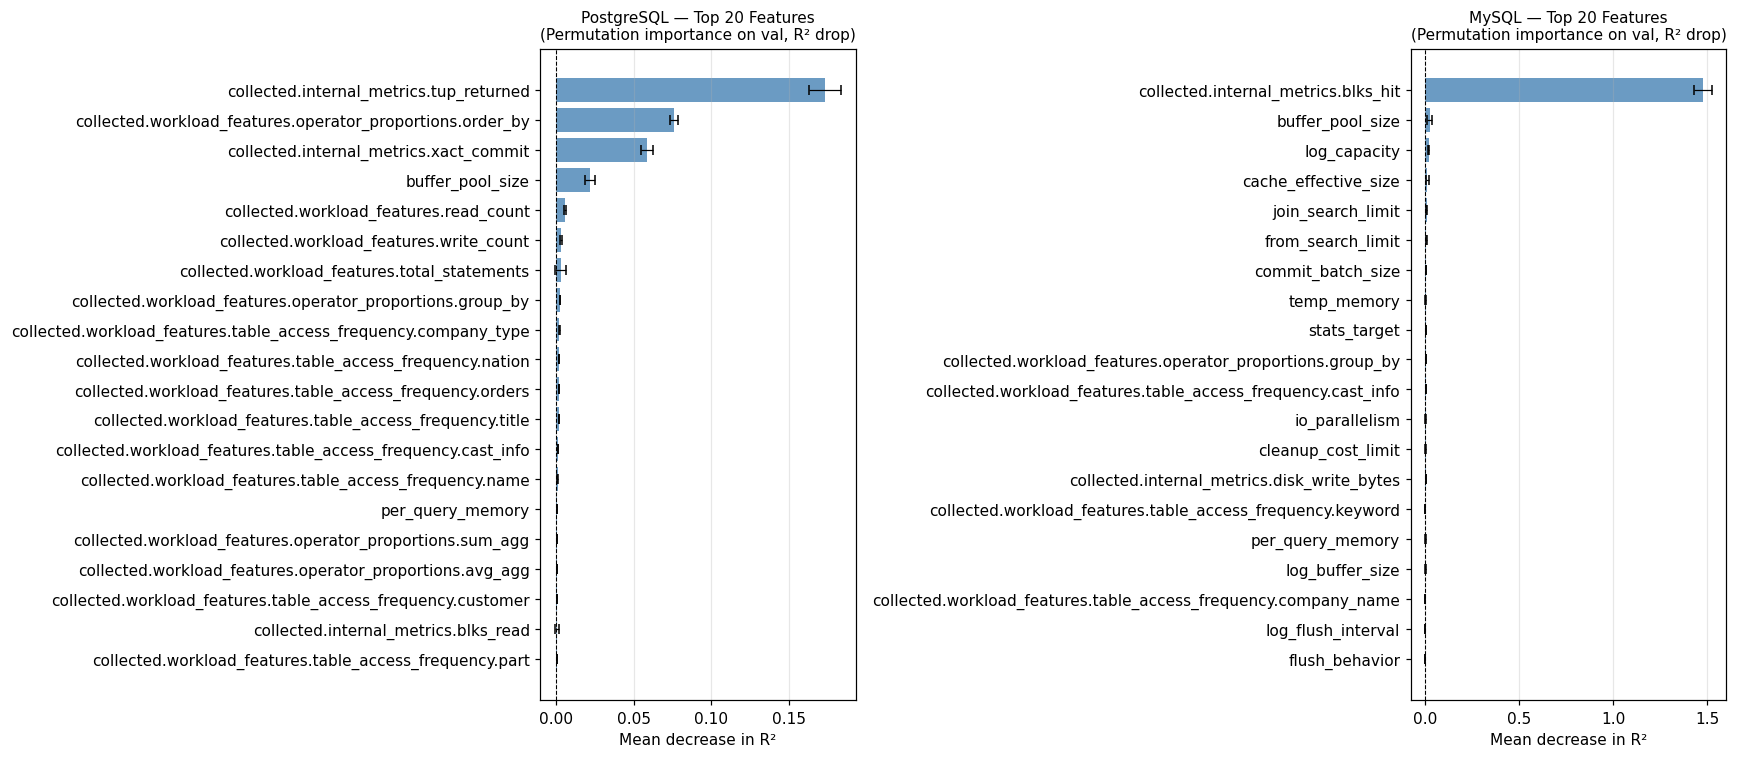


PostgreSQL top 20:
                                                        feature  importance      std
                        collected.internal_metrics.tup_returned    0.173210 0.010573
      collected.workload_features.operator_proportions.order_by    0.075803 0.002495
                         collected.internal_metrics.xact_commit    0.058491 0.004091
                                               buffer_pool_size    0.021609 0.003145
                         collected.workload_features.read_count    0.005660 0.000540
                        collected.workload_features.write_count    0.003115 0.000520
                   collected.workload_features.total_statements    0.002691 0.003518
      collected.workload_features.operator_proportions.group_by    0.002264 0.000208
collected.workload_features.table_access_frequency.company_type    0.001974 0.000094
      collected.workload_features.table_access_frequency.nation    0.001725 0.000064
      collected.workload_features.table_acces

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, imp_df, title in [
    (axes[0], pg_imp_df, 'PostgreSQL — Top 20 Features'),
    (axes[1], my_imp_df, 'MySQL — Top 20 Features'),
]:
    top20 = imp_df.head(20)
    ax.barh(top20['feature'][::-1], top20['importance'][::-1],
            xerr=top20['std'][::-1], color='steelblue', alpha=0.8,
            error_kw=dict(elinewidth=0.8, capsize=3))
    ax.set_title(f'{title}\n(Permutation importance on val, R² drop)', fontsize=10)
    ax.set_xlabel('Mean decrease in R²')
    ax.axvline(0, color='black', lw=0.7, ls='--')
    ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nPostgreSQL top 20:'); print(pg_imp_df.head(20).to_string(index=False))
print('\nMySQL top 20:');      print(my_imp_df.head(20).to_string(index=False))

## 9. Feature Subset Comparison

Compare all / top-40 / top-20 on the val set. Pick the best for full training.

In [38]:
subset_rows = []
for engine, tr, val_df, top_feats in [
    ('postgresql', pg_train, pg_ref_val, pg_top_feats),
    ('mysql',      my_train, my_ref_val, my_top_feats),
]:
    for sname, sfeats in [('all', ALL_FEAT_COLS), ('top40', top_feats[:40]), ('top20', top_feats[:20])]:
        row = eval_group(engine, tr, val_df, sname, sfeats)
        subset_rows.append(row)
        print(f'{engine:12s} | {sname:6s} ({row["n_feats"]:3d} feats) '
              f'wl_sp={row["wl_sp"]:.4f}  sp={row["sp"]:.4f}')

subset_df  = pd.DataFrame(subset_rows)
best_sub   = subset_df.loc[subset_df.groupby('engine')['wl_sp'].idxmax()]
print('\nBest subset per engine:')
print(best_sub[['engine','group','n_feats','wl_sp','sp']].to_string(index=False))

def pick_feats(engine, best_sub, top_feats):
    g = best_sub[best_sub['engine']==engine]['group'].values[0]
    return ALL_FEAT_COLS if g=='all' else top_feats[:40] if g=='top40' else top_feats[:20]

pg_best_feats = pick_feats('postgresql', best_sub, pg_top_feats)
my_best_feats = pick_feats('mysql',      best_sub, my_top_feats)
print(f'\nUsing {len(pg_best_feats)} features for PostgreSQL')
print(f'Using {len(my_best_feats)} features for MySQL')

postgresql   | all    (149 feats) wl_sp=0.4064  sp=0.6614
postgresql   | top40  ( 40 feats) wl_sp=0.3804  sp=0.7612
postgresql   | top20  ( 20 feats) wl_sp=0.4168  sp=0.7480
mysql        | all    ( 83 feats) wl_sp=0.7787  sp=0.5947
mysql        | top40  ( 40 feats) wl_sp=0.8238  sp=0.6772
mysql        | top20  ( 20 feats) wl_sp=0.8209  sp=0.6720

Best subset per engine:
    engine group  n_feats  wl_sp     sp
     mysql top40       40 0.8238 0.6772
postgresql top20       20 0.4168 0.7480

Using 20 features for PostgreSQL
Using 40 features for MySQL


## 10. WorkloadGroupKFold

Custom cross-validator: all rows from the same workload stay in the
same fold, preventing workload leakage across CV splits.

In [39]:
class WorkloadGroupKFold(BaseCrossValidator):

    """

    K-fold where fold boundaries fall on workload boundaries.

    Pass workload labels as `groups` to split().

    """

    def __init__(self, n_splits=5, shuffle=True, random_state=SEED):

        self.n_splits     = n_splits

        self.shuffle      = shuffle

        self.random_state = random_state



    def split(self, X, y=None, groups=None):

        if groups is None: raise ValueError('groups required')

        groups = np.asarray(groups)

        wls    = np.unique(groups)

        rng    = np.random.RandomState(self.random_state)

        if self.shuffle: rng.shuffle(wls)

        wl_fold  = {w: i % self.n_splits for i, w in enumerate(wls)}

        fold_arr = np.array([wl_fold[g] for g in groups])

        for f in range(self.n_splits):

            yield np.where(fold_arr != f)[0], np.where(fold_arr == f)[0]



    def get_n_splits(self, X=None, y=None, groups=None): return self.n_splits





def run_cv(model, train_val_df, feat_cols, n_splits=5, label=''):

    cols = [c for c in feat_cols if c in train_val_df.columns]

    if not cols:

        raise ValueError(f'No usable features for CV: {label}')



    non_empty = ~train_val_df[cols].isna().all(axis=0)

    cols = [c for c in cols if bool(non_empty.get(c, True))]

    if not cols:

        raise ValueError(f'All candidate features are empty/NaN for CV: {label}')



    imp   = SimpleImputer(strategy='median')

    X_all = imp.fit_transform(train_val_df[cols])

    X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

    y_all = train_val_df['cost'].to_numpy(np.float64)

    wl_all  = train_val_df['workload'].to_numpy()



    cv = WorkloadGroupKFold(n_splits=n_splits)

    fold_results = []

    for fold_i, (tr_idx, te_idx) in enumerate(cv.split(X_all, y_all, groups=wl_all), 1):

        m = clone(model)

        m.fit(X_all[tr_idx], y_all[tr_idx])

        pred     = m.predict(X_all[te_idx])

        wl_sp, n = workload_spearman_macro(y_all[te_idx], pred, wl_all[te_idx])

        sp       = safe_spearman(y_all[te_idx], pred)

        top3     = within_topk_accuracy(y_all[te_idx], pred, wl_all[te_idx])

        fold_results.append(dict(fold=fold_i, wl_spearman=round(wl_sp,4),

                                  spearman=round(sp,4), top3_acc=round(top3,4), n_wls=n))



    fold_df = pd.DataFrame(fold_results)

    return fold_df, {

        'label':     label,

        'wl_sp_mean':  round(fold_df['wl_spearman'].mean(), 4),

        'wl_sp_std':   round(fold_df['wl_spearman'].std(),  4),

        'sp_mean':     round(fold_df['spearman'].mean(),    4),

        'sp_std':      round(fold_df['spearman'].std(),     4),

        'top3_mean':   round(fold_df['top3_acc'].mean(),    4),

    }





print('WorkloadGroupKFold and CV runner defined.')


WorkloadGroupKFold and CV runner defined.


## 11. Build Models

In [40]:
from sklearn.compose import TransformedTargetRegressor

def make_models(seed=SEED):
    rf_base = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,        # full trees — RF avoids overfit via bagging
        min_samples_leaf=3,
        max_features=0.4,      # feature subsampling per split
        bootstrap=True,
        n_jobs=-1,
        random_state=seed,
    )
    gbm_base = HistGradientBoostingRegressor(
        loss='absolute_error', # robust to targets scale/outliers
        max_iter=500,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=10,
        l2_regularization=0.1,
        max_bins=255,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=seed,
    )
    voting_base = VotingRegressor(
        estimators=[('rf', clone(rf_base)), ('gbm', clone(gbm_base))],
        weights=[1, 1],
        n_jobs=-1,
    )
    
    # Wrap all models so they fit on log1p(cost) and predict expm1(cost)
    rf = TransformedTargetRegressor(regressor=rf_base, func=np.log1p, inverse_func=np.expm1)
    gbm = TransformedTargetRegressor(regressor=gbm_base, func=np.log1p, inverse_func=np.expm1)
    voting = TransformedTargetRegressor(regressor=voting_base, func=np.log1p, inverse_func=np.expm1)
    
    return rf, gbm, voting

pg_rf, pg_gbm, pg_voting = make_models()
my_rf, my_gbm, my_voting = make_models()
print('Model instances created.')

Model instances created.


## 12. Cross-Validation (train + val, test still locked)

5-fold WorkloadGroupKFold on the combined train+val set.
Gives an honest CV estimate before the final test evaluation.

In [41]:
cv_rows = []

for engine, tr, va, best_feats, rf, gbm, voting in [
    ('postgresql', pg_train, pg_val, pg_best_feats, pg_rf, pg_gbm, pg_voting),
    ('mysql',      my_train, my_val, my_best_feats, my_rf, my_gbm, my_voting),
]:
    train_val = pd.concat([tr, va]).copy() if not va.empty else tr.copy()
    print(f'\n=== {engine.upper()} — 5-Fold WorkloadGroupKFold CV '
          f'({len(train_val)} rows, {train_val["workload"].nunique()} workloads) ===')

    for model_name, model in [('RF', rf), ('GBM', gbm), ('Voting', voting)]:
        fold_df, summ = run_cv(model, train_val, best_feats, n_splits=5,
                                label=f'{engine}_{model_name}')
        summ['engine'] = engine
        summ['model']  = model_name
        cv_rows.append(summ)
        print(f'  {model_name:6s}  wl_sp={summ["wl_sp_mean"]:.4f}±{summ["wl_sp_std"]:.4f}  '
              f'sp={summ["sp_mean"]:.4f}±{summ["sp_std"]:.4f}  '
              f'top3={summ["top3_mean"]:.4f}')
        print(f'          per-fold wl_sp: {fold_df["wl_spearman"].tolist()}')

cv_df = pd.DataFrame(cv_rows)
print('\n=== CV Summary ===')
print(cv_df[['engine','model','wl_sp_mean','wl_sp_std','sp_mean','top3_mean']].to_string(index=False))


=== POSTGRESQL — 5-Fold WorkloadGroupKFold CV (10650 rows, 109 workloads) ===
  RF      wl_sp=0.2344±0.0613  sp=0.8774±0.0564  top3=0.1094
          per-fold wl_sp: [0.2781, 0.252, 0.2109, 0.2914, 0.1396]
  GBM     wl_sp=0.2506±0.0764  sp=0.8757±0.0430  top3=0.1094
          per-fold wl_sp: [0.2653, 0.2185, 0.1577, 0.3664, 0.2449]
  Voting  wl_sp=0.2650±0.0970  sp=0.8827±0.0424  top3=0.1108
          per-fold wl_sp: [0.297, 0.2622, 0.2187, 0.4045, 0.1426]

=== MYSQL — 5-Fold WorkloadGroupKFold CV (927 rows, 11 workloads) ===
  RF      wl_sp=0.3955±0.2137  sp=-0.3985±0.3161  top3=0.2770
          per-fold wl_sp: [0.4714, 0.1525, 0.6369, 0.1896, 0.5269]
  GBM     wl_sp=0.4023±0.2209  sp=-0.1134±0.4820  top3=0.2607
          per-fold wl_sp: [0.5052, 0.0977, 0.674, 0.4552, 0.2793]
  Voting  wl_sp=0.4470±0.2049  sp=-0.3844±0.2980  top3=0.2839
          per-fold wl_sp: [0.4577, 0.129, 0.6934, 0.4321, 0.5227]

=== CV Summary ===
    engine  model  wl_sp_mean  wl_sp_std  sp_mean  top3_mean
po

## 13. Final Training on Full Train + Val

In [42]:
TRAINED = {}   # (engine, model_name) -> (fitted_model, imputer, feat_cols)



for engine, tr, va, best_feats, rf, gbm, voting in [

    ('postgresql', pg_train, pg_val, pg_best_feats, pg_rf, pg_gbm, pg_voting),

    ('mysql',      my_train, my_val, my_best_feats, my_rf, my_gbm, my_voting),

]:

    train_val = pd.concat([tr, va]).copy() if not va.empty else tr.copy()

    cols = [c for c in best_feats if c in train_val.columns]

    non_empty = ~train_val[cols].isna().all(axis=0) if cols else pd.Series([], dtype=bool)

    cols = [c for c in cols if bool(non_empty.get(c, True))]



    if not cols:

        raise RuntimeError(f'No usable (non-empty) features for engine={engine}')



    imp  = SimpleImputer(strategy='median')

    X_tv = imp.fit_transform(train_val[cols])

    X_tv = np.nan_to_num(X_tv, nan=0.0, posinf=0.0, neginf=0.0)

    y_tv = train_val['cost'].to_numpy(np.float64)



    print(f'\nTraining {engine.upper()} — {len(train_val)} rows, {len(cols)} features...')

    for model_name, model in [('RF', rf), ('GBM', gbm), ('Voting', voting)]:

        m = clone(model)

        m.fit(X_tv, y_tv)

        TRAINED[(engine, model_name)] = (m, imp, cols)

        print(f'  {model_name} — done.')



print('\nAll models trained.')



Training POSTGRESQL — 10650 rows, 20 features...
  RF — done.
  GBM — done.
  Voting — done.

Training MYSQL — 927 rows, 40 features...
  RF — done.
  GBM — done.
  Voting — done.

All models trained.


## 14. Held-Out Test Evaluation

**First and only time the test set is used.**

In [43]:
test_results = []



for engine, te in [('postgresql', pg_test), ('mysql', my_test)]:

    print(f'\n=== {engine.upper()} — Held-Out Test '

          f'({len(te)} rows, {te["workload"].nunique()} workloads) ===')

    y_te   = te['cost'].to_numpy(np.float64)

    wl_te  = te['workload'].to_numpy()

    ram_te = te['ram_gb'].to_numpy()



    for model_name in ['RF', 'GBM', 'Voting']:

        m, imp, cols = TRAINED[(engine, model_name)]

        X_te = imp.transform(te[cols])

        X_te = np.nan_to_num(X_te, nan=0.0, posinf=0.0, neginf=0.0)

        pred = m.predict(X_te)

        res  = full_eval(y_te, pred, wl_te, ram=ram_te, label=f'{engine}_{model_name}')

        res['engine'] = engine

        res['model']  = model_name

        test_results.append(res)



        print(f'  {model_name:6s}  '

              f'wl_sp={res["workload_spearman_macro"]:.4f}  '

              f'sp={res["overall_spearman"]:.4f}  '

              f'top3={res["top3_rank_accuracy"]:.4f}  '

              f'mape={res["mape_pct"]:.1f}%  '

              f'(n_wls={res["n_workloads_evaluated"]})')

        if not res['subgroup'].empty:

            print('    subgroup:')

            for _, row in res['subgroup'].iterrows():

                print(f'      RAM {int(row.ram_gb)}GB  n={int(row.n)}  '

                      f'sp={row.spearman}  wl_sp={row.wl_spearman}  top3={row.top3_acc}')



=== POSTGRESQL — Held-Out Test (2891 rows, 30 workloads) ===
  RF      wl_sp=0.1863  sp=0.9040  top3=0.0997  mape=277.3%  (n_wls=30)
    subgroup:
      RAM 32GB  n=303  sp=0.5475  wl_sp=0.3509  top3=0.1122
      RAM 64GB  n=2588  sp=0.9096  wl_sp=0.168  top3=0.0983
  GBM     wl_sp=0.3367  sp=0.9000  top3=0.1196  mape=537.9%  (n_wls=30)
    subgroup:
      RAM 32GB  n=303  sp=0.5555  wl_sp=0.4319  top3=0.1353
      RAM 64GB  n=2588  sp=0.9041  wl_sp=0.3262  top3=0.1179
  Voting  wl_sp=0.2562  sp=0.8989  top3=0.1075  mape=398.1%  (n_wls=30)
    subgroup:
      RAM 32GB  n=303  sp=0.5546  wl_sp=0.4143  top3=0.1485
      RAM 64GB  n=2588  sp=0.9039  wl_sp=0.2386  top3=0.1029

=== MYSQL — Held-Out Test (306 rows, 5 workloads) ===
  RF      wl_sp=0.3539  sp=0.8902  top3=0.4763  mape=84.8%  (n_wls=5)
    subgroup:
      RAM 32GB  n=297  sp=0.8888  wl_sp=0.4088  top3=0.1346
      RAM 64GB  n=9  sp=0.0333  wl_sp=0.5  top3=1.0
  GBM     wl_sp=0.1813  sp=0.9169  top3=0.4689  mape=80.9%  (n_wls=

## 15. Results Summary

In [44]:
summary = pd.DataFrame([{
    'engine':                 r['engine'],
    'model':                  r['model'],
    'wl_spearman_macro':      r['workload_spearman_macro'],
    'overall_spearman':       r['overall_spearman'],
    'top3_rank_accuracy':     r['top3_rank_accuracy'],
    'mape_pct':               r['mape_pct'],
    'n_workloads_evaluated':  r['n_workloads_evaluated'],
} for r in test_results])

print('=== FULL RESULTS TABLE ===')
print(summary.to_string(index=False))

print('\n=== BEST MODEL PER ENGINE ===')
best = summary.loc[summary.groupby('engine')['wl_spearman_macro'].idxmax()]
print(best[['engine','model','wl_spearman_macro','overall_spearman',
             'top3_rank_accuracy','mape_pct']].to_string(index=False))

print('\nTarget: wl_spearman_macro > 0.5')
for _, row in best.iterrows():
    flag = '✓' if row['wl_spearman_macro'] > 0.5 else '✗'
    print(f'  {row["engine"]:12s} ({row["model"]:6s}): {row["wl_spearman_macro"]:.4f}  {flag}')

=== FULL RESULTS TABLE ===
    engine  model  wl_spearman_macro  overall_spearman  top3_rank_accuracy  mape_pct  n_workloads_evaluated
postgresql     RF             0.1863            0.9040              0.0997    277.34                     30
postgresql    GBM             0.3367            0.9000              0.1196    537.87                     30
postgresql Voting             0.2562            0.8989              0.1075    398.13                     30
     mysql     RF             0.3539            0.8902              0.4763     84.75                      5
     mysql    GBM             0.1813            0.9169              0.4689     80.86                      5
     mysql Voting             0.3361            0.9283              0.4744     82.64                      5

=== BEST MODEL PER ENGINE ===
    engine model  wl_spearman_macro  overall_spearman  top3_rank_accuracy  mape_pct
     mysql    RF             0.3539            0.8902              0.4763     84.75
postgresql   GBM  

## 16. Visualizations

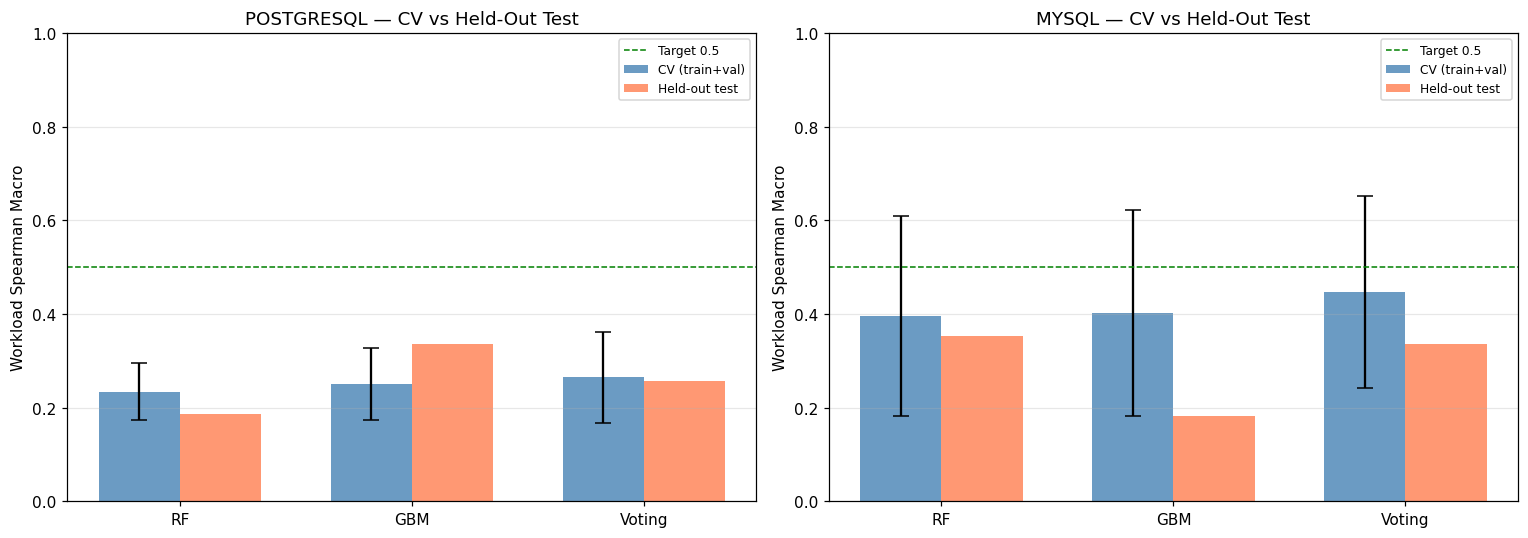

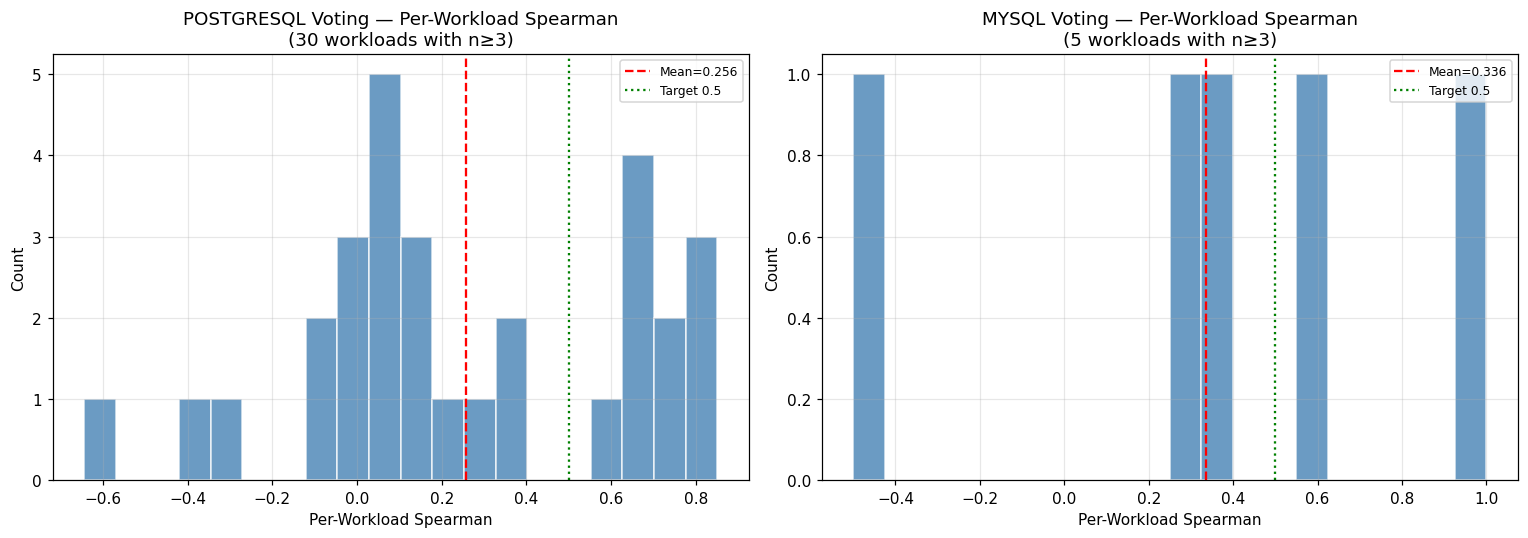

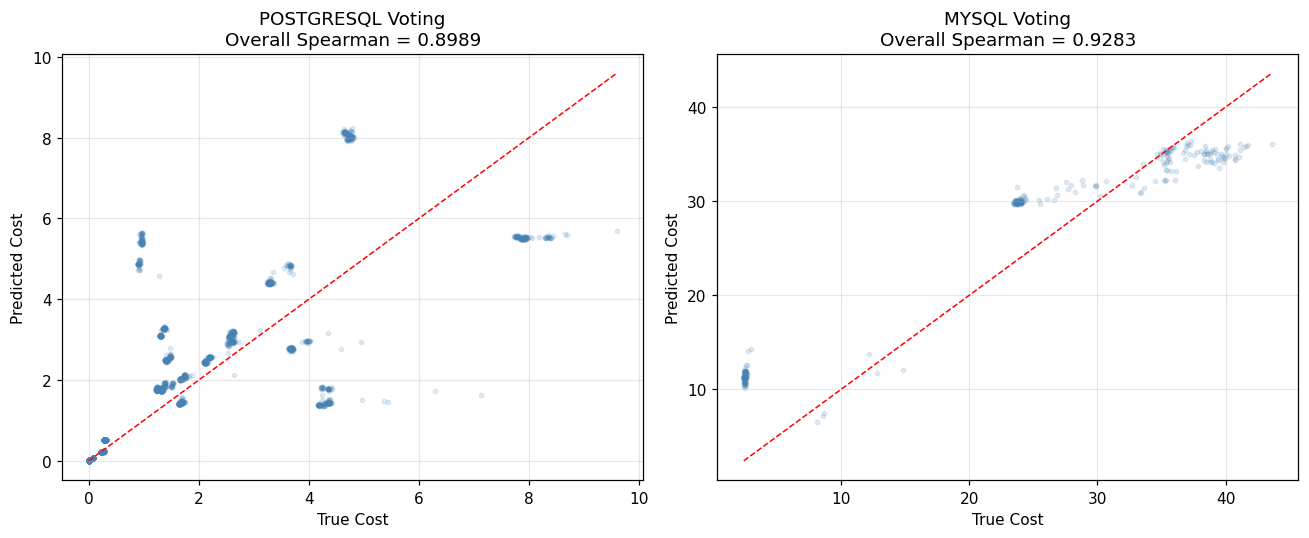

In [45]:
# ── Plot 1: CV vs Test ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, engine in zip(axes, ['postgresql', 'mysql']):
    models   = ['RF', 'GBM', 'Voting']
    x, w     = np.arange(len(models)), 0.35
    cv_sub   = cv_df[cv_df['engine']==engine]
    te_sub   = summary[summary['engine']==engine]
    cv_means = [cv_sub[cv_sub['model']==m]['wl_sp_mean'].values[0]  for m in models]
    cv_stds  = [cv_sub[cv_sub['model']==m]['wl_sp_std'].values[0]   for m in models]
    te_means = [te_sub[te_sub['model']==m]['wl_spearman_macro'].values[0] for m in models]
    ax.bar(x-w/2, cv_means, w, yerr=cv_stds, label='CV (train+val)',
           color='steelblue', alpha=0.8, capsize=5)
    ax.bar(x+w/2, te_means, w, label='Held-out test',
           color='coral', alpha=0.8)
    ax.axhline(0.5, color='green', ls='--', lw=1, label='Target 0.5')
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_ylabel('Workload Spearman Macro'); ax.set_ylim(0, 1)
    ax.set_title(f'{engine.upper()} — CV vs Held-Out Test')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_vs_test.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 2: Per-workload Spearman distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, engine, te in zip(axes, ['postgresql','mysql'], [pg_test, my_test]):
    m, imp, cols = TRAINED[(engine, 'Voting')]
    pred = m.predict(imp.transform(te[cols]))
    y_te = te['cost'].to_numpy(); wl_te = te['workload'].to_numpy()
    wl_sps = [safe_spearman(y_te[wl_te==w], pred[wl_te==w])
               for w in np.unique(wl_te) if (wl_te==w).sum()>=3]
    wl_sps = [s for s in wl_sps if not np.isnan(s)]
    ax.hist(wl_sps, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(wl_sps), color='red', ls='--', label=f'Mean={np.mean(wl_sps):.3f}')
    ax.axvline(0.5, color='green', ls=':', label='Target 0.5')
    ax.set_xlabel('Per-Workload Spearman'); ax.set_ylabel('Count')
    ax.set_title(f'{engine.upper()} Voting — Per-Workload Spearman\n({len(wl_sps)} workloads with n≥3)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('per_workload_spearman.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 3: Predicted vs Actual scatter (Voting, test set) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, engine, te in zip(axes, ['postgresql','mysql'], [pg_test, my_test]):
    m, imp, cols = TRAINED[(engine, 'Voting')]
    pred = m.predict(imp.transform(te[cols]))
    y_te = te['cost'].to_numpy()
    ax.scatter(y_te, pred, alpha=0.15, s=8, color='steelblue')
    mn, mx = min(y_te.min(), pred.min()), max(y_te.max(), pred.max())
    ax.plot([mn,mx],[mn,mx], 'r--', lw=1)
    sp = safe_spearman(y_te, pred)
    ax.set_xlabel('True Cost'); ax.set_ylabel('Predicted Cost')
    ax.set_title(f'{engine.upper()} Voting\nOverall Spearman = {sp:.4f}')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=130, bbox_inches='tight')
plt.show()

## 17. Per-Workload Breakdown (Voting)

In [46]:
for engine, te in [('postgresql', pg_test), ('mysql', my_test)]:
    m, imp, cols = TRAINED[(engine, 'Voting')]
    pred  = m.predict(imp.transform(te[cols]))
    y_te  = te['cost'].to_numpy()
    wl_te = te['workload'].to_numpy()

    rows = []
    for w in np.unique(wl_te):
        mask = wl_te == w
        rows.append(dict(
            workload = w,
            n        = int(mask.sum()),
            spearman = round(safe_spearman(y_te[mask], pred[mask]), 4),
            pred_std = round(float(pred[mask].std()), 4),
            true_std = round(float(y_te[mask].std()),  4),
            top3_acc = round(within_topk_accuracy(
                y_te[mask], pred[mask], np.full(mask.sum(), w)), 4),
        ))
    wl_df = pd.DataFrame(rows).sort_values('n', ascending=False)
    print(f'\n=== {engine.upper()} — Per-Workload (Voting) ===')
    print(wl_df.to_string(index=False))
    low_var = (wl_df['pred_std'] < 0.05).sum()
    small_n = (wl_df['n'] < 3).sum()
    print(f'  Workloads with near-zero pred variance (pred_std<0.05): {low_var}')
    print(f'  Workloads excluded from macro (n<3):                    {small_n}')


=== POSTGRESQL — Per-Workload (Voting) ===
                  workload   n  spearman  pred_std  true_std  top3_acc
                     job_1 101    0.4007    0.0083    0.0212    0.1386
 sample_wikipedia_config10 101    0.1417    0.0000    0.0002    0.0594
                  tpch_256 101    0.7865    0.0925    0.0351    0.1782
                  tpch_140 101    0.7120    0.0617    0.0431    0.1683
                 tpcds_112 101    0.2574    0.0008    0.0014    0.0693
          ssb_flat_tiny_72 101   -0.0014    0.0304    0.2644    0.0792
          ssb_flat_tiny_71 101   -0.3567    0.0742    0.0510    0.0198
                   ssb_223 101    0.6836    0.0601    0.0623    0.1287
                    ssb_21 101    0.3850    0.0736    0.1853    0.1287
                   ssb_190 101    0.5782    0.1713    0.1521    0.1683
                   ssb_188 101    0.6747    0.0594    0.0737    0.1485
sample_wikipedia_config170 101    0.1046    0.0000    0.0000    0.0693
sample_wikipedia_config135 101   

In [ ]:
import joblib
from pathlib import Path

# Kaggle writable directory
out_path = Path("/kaggle/working/voting_model.pkl")

# Save the trained model object
joblib.dump(voting, out_path)

print(f"Model saved to: {out_path}")
print(f"File size: {out_path.stat().st_size / (1024**2):.2f} MB")